# PPA Analysis — Triplet SNN ASIC Flow

Synthesize pair-based, triplet, and dynamic SNN designs using LibreLane (OpenLane) targeting Sky130.
Compare area, power, and timing to quantify hardware overhead of triplet STDP.

In [60]:
import json
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Paths — PPA_ROOT is auto-detected as the directory containing this notebook
PPA_ROOT = os.path.dirname(os.path.abspath("__file__"))  # ppa/

# Load architecture definitions from ground truth
with open(os.path.join(PPA_ROOT, "architectures.json")) as f:
    ARCH_CONFIG = json.load(f)

DEFAULTS = ARCH_CONFIG["defaults"]

# Build DESIGNS dict: label -> config directory name (arch key)
DESIGNS = {v["label"]: k for k, v in ARCH_CONFIG["architectures"].items()}

print(f"PPA root: {PPA_ROOT}")
print(f"Designs ({len(DESIGNS)}):")
for label, key in DESIGNS.items():
    arch = ARCH_CONFIG["architectures"][key]
    print(f"  [{arch['group']}] {label} -> {key}/ ({arch['rtl_file']})")

PPA root: /Users/dakotabarnes/Develop/274/triplet-snn/ppa
Designs (8):
  [baseline] Original Pair -> original_pair/ (snn_network.v)
  [baseline] Pair -> pair/ (snn_dynamic.v)
  [baseline] Triplet -> triplet/ (snn_dynamic.v)
  [optimized] Triplet Optimized -> triplet_optimized/ (snn_dynamic_optimized.v)
  [optimized] Triplet Opt. Spike-Gated -> triplet_optimized_spike_gated/ (snn_dynamic_optimized.v)
  [optimized] Triplet Opt. Nearest-Neighbor -> triplet_optimized_nn/ (snn_dynamic_optimized.v)
  [optimized] Triplet Opt. Seg. Adder -> triplet_optimized_seg_adder/ (snn_dynamic_optimized.v)
  [optimized] Triplet Opt. LUT-STDP -> triplet_optimized_lut_stdp/ (snn_dynamic_optimized.v)


## Generate LibreLane Configs

Run this cell to (re)generate per-design `config.json` files from `architectures.json`.
Each design gets a folder `ppa/<arch_key>/config.json` suitable for `python3 -m librelane`.

In [61]:
for arch_key, arch in ARCH_CONFIG["architectures"].items():
    design_dir = os.path.join(PPA_ROOT, arch_key)
    os.makedirs(design_dir, exist_ok=True)

    rtl_file = arch["rtl_file"]
    # snn_network.v uses its own module name; all others use snn_dynamic variants
    design_name = rtl_file.replace(".v", "")

    # Merge default defines with any per-architecture defines
    verilog_defines = list(DEFAULTS["verilog_defines"])
    if arch.get("verilog_defines"):
        verilog_defines.extend(arch["verilog_defines"])

    config = {
        "DESIGN_NAME": design_name,
        "VERILOG_FILES": [f"dir::../../rtl/{rtl_file}"],
        "CLOCK_PERIOD": DEFAULTS["clock_period"],
        "CLOCK_PORT": DEFAULTS["clock_port"],
        "VERILOG_DEFINES": verilog_defines,
        "ERROR_ON_SYNTH_CHECKS": DEFAULTS["error_on_synth_checks"],
    }

    if arch["synth_parameters"]:
        config["SYNTH_PARAMETERS"] = [
            f"{k}={v}" for k, v in arch["synth_parameters"].items()
        ]

    # Add include dirs if specified (e.g. for LUT-based STDP .vh files)
    if arch.get("verilog_include_dirs"):
        config["VERILOG_INCLUDE_DIRS"] = [
            f"dir::{d}" for d in arch["verilog_include_dirs"]
        ]

    config_path = os.path.join(design_dir, "config.json")
    with open(config_path, "w") as f:
        json.dump(config, f, indent=2)
        f.write("\n")
    print(f"  Wrote {arch_key}/config.json  ({arch['label']})")

print(f"\nGenerated {len(ARCH_CONFIG['architectures'])} configs.")

  Wrote original_pair/config.json  (Original Pair)
  Wrote pair/config.json  (Pair)
  Wrote triplet/config.json  (Triplet)
  Wrote triplet_optimized/config.json  (Triplet Optimized)
  Wrote triplet_optimized_spike_gated/config.json  (Triplet Opt. Spike-Gated)
  Wrote triplet_optimized_nn/config.json  (Triplet Opt. Nearest-Neighbor)
  Wrote triplet_optimized_seg_adder/config.json  (Triplet Opt. Seg. Adder)
  Wrote triplet_optimized_lut_stdp/config.json  (Triplet Opt. LUT-STDP)

Generated 8 configs.


## Run LibreLane

LibreLane must be run from within its nix shell. See `README.md` for installation instructions.

Set `PARALLEL = True` and adjust `MAX_WORKERS` to run designs concurrently.

**To run a single design:** Set `RUN_ONLY` to a folder name (e.g. `"triplet_optimized_spike_gated"`).
Set to `None` to run all designs.

In [62]:
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed

LIBRELANE_SHELL = os.environ.get("LIBRELANE_SHELL", "")
if not LIBRELANE_SHELL:
    print("WARNING: $LIBRELANE_SHELL not set. Set it to your LibreLane shell.nix path to run from here.")
    print("You can still run designs manually from a terminal — see README.md")

def run_librelane(label, config_path):
    """Run LibreLane via nix-shell so dependencies are available."""
    if not LIBRELANE_SHELL:
        return label, 1, "$LIBRELANE_SHELL not set"
    cmd = f'nix-shell {LIBRELANE_SHELL} --run "python3 -m librelane {config_path}"'
    result = subprocess.run(cmd, shell=True, cwd=PPA_ROOT,
                            capture_output=True, text=True)
    err = result.stderr[-500:] if result.stderr else ""
    return label, result.returncode, err

# --- Configuration ---
PARALLEL = True   # Set False for sequential execution
MAX_WORKERS = 4   # Number of parallel LibreLane jobs

# Set to a folder name to run only that design, or None to run all:
# RUN_ONLY = None
# RUN_ONLY = "triplet_optimized"
# RUN_ONLY = "triplet_optimized_spike_gated"
RUN_ONLY = "triplet_optimized_seg_adder"

# Build job list (filtered by RUN_ONLY if set)
# if RUN_ONLY:
#     if RUN_ONLY not in DESIGNS.values():
#         raise ValueError(f"Unknown design folder: {RUN_ONLY!r}. Valid: {list(DESIGNS.values())}")
#     jobs = {label: os.path.join(PPA_ROOT, ddir, "config.json")
#             for label, ddir in DESIGNS.items() if ddir == RUN_ONLY}
# else:
#     jobs = {label: os.path.join(PPA_ROOT, ddir, "config.json")
#             for label, ddir in DESIGNS.items()}

# if PARALLEL and len(jobs) > 1:
#     print(f"Running {len(jobs)} designs in parallel (max {MAX_WORKERS} workers)...\n")
#     with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
#         futures = {pool.submit(run_librelane, label, path): label
#                    for label, path in jobs.items()}
#         for future in as_completed(futures):
#             label, rc, err = future.result()
#             status = "OK" if rc == 0 else f"FAILED (exit {rc})"
#             print(f"  {label}: {status}")
#             if rc != 0:
#                 print(f"    {err}")
# else:
#     print(f"Running {len(jobs)} design(s) sequentially...\n")
#     for label, path in jobs.items():
#         print(f"  Running: {label} ...", end=" ", flush=True)
#         _, rc, err = run_librelane(label, path)
#         print("OK" if rc == 0 else f"FAILED (exit {rc})")
#         if rc != 0:
#             print(f"    {err}")
#             break

## Load Metrics

Parse `runs/*/final/metrics.json` from each design's latest run.

In [63]:
def find_latest_metrics(design_dir):
    """Find the most recent metrics.json for a design."""
    pattern = os.path.join(PPA_ROOT, design_dir, "runs", "*", "final", "metrics.json")
    files = sorted(glob.glob(pattern))
    if not files:
        return None
    return files[-1]  # latest by name (timestamp-based run dirs sort chronologically)

def load_metrics(design_dir):
    """Load metrics from the latest run."""
    path = find_latest_metrics(design_dir)
    if path is None:
        return None
    with open(path) as f:
        return json.load(f)

# Load all available metrics
rows = []
for label, design_dir in DESIGNS.items():
    m = load_metrics(design_dir)
    if m is None:
        print(f"WARNING: No metrics found for {label} ({design_dir}/)")
        continue
    rows.append({
        "Design": label,
        "Instances": m.get("design__instance__count"),
        "Area (um2)": m.get("design__instance__area"),
        "Internal Power (W)": m.get("power__internal__total"),
        "Switching Power (W)": m.get("power__switching__total"),
        "Leakage Power (W)": m.get("power__leakage__total"),
        "Total Power (W)": m.get("power__total"),
        "Setup Slack (ns)": m.get("timing__setup__ws__corner:nom_tt_025C_1v80"),
        "Setup WNS (ns)": m.get("timing__setup__wns__corner:nom_tt_025C_1v80"),
        "Setup TNS (ns)": m.get("timing__setup__tns__corner:nom_tt_025C_1v80"),
        "Hold WNS (ns)": m.get("timing__hold__wns__corner:nom_tt_025C_1v80"),
        "Hold TNS (ns)": m.get("timing__hold__tns__corner:nom_tt_025C_1v80"),
        "_metrics_path": find_latest_metrics(design_dir),
    })

if rows:
    df = pd.DataFrame(rows)
    print(f"Loaded metrics for {len(df)} designs")
else:
    df = pd.DataFrame()
    print("No metrics found yet. Run LibreLane first.")

Loaded metrics for 8 designs


## PPA Comparison Table

In [64]:
if not df.empty:
    CLOCK_PERIOD = 25  # ns
    # Setup Slack is positive slack; max freq = 1 / (period - slack)
    df["Max Freq (MHz)"] = df["Setup Slack (ns)"].apply(
        lambda ws: 1000.0 / (CLOCK_PERIOD - ws) if pd.notna(ws) and (CLOCK_PERIOD - ws) > 0 else None
    )
    display_cols = [c for c in df.columns if not c.startswith("_")]
    print("PPA Comparison — Sky130 HD @ 25 ns")
    display(df[display_cols].round(4))
else:
    print("No data to display.")

PPA Comparison — Sky130 HD @ 25 ns


,Design,Instances,Area (um2),Internal Power (W),Switching Power (W),Leakage Power (W),Total Power (W),Setup Slack (ns),Setup WNS (ns),Setup TNS (ns),Hold WNS (ns),Hold TNS (ns),Max Freq (MHz)
0,Original Pair,2849,19478.7,0.0049,0.0057,0.0,0.0106,6.6975,0,0,0,0,54.6375
1,Pair,4641,35181.2,0.0329,0.0388,0.0,0.0717,6.1161,0,0,0,0,52.9553
2,Triplet,14651,92765.2,0.0399,0.0518,0.0,0.0917,5.3039,0,0,0,0,50.7715
3,Triplet Optimized,14724,93233.2,0.0389,0.0504,0.0,0.0893,5.1233,0,0,0,0,50.3103
4,Triplet Opt. Spike-Gated,14708,92695.2,0.0369,0.0470,0.0,0.0838,5.1157,0,0,0,0,50.2909
5,Triplet Opt. Nearest-Neighbor,12165,79366.1,0.0289,0.0389,0.0,0.0678,4.3630,0,0,0,0,48.4567
6,Triplet Opt. Seg. Adder,14534,92314.8,0.0288,0.0366,0.0,0.0654,5.7704,0,0,0,0,52.0032
7,Triplet Opt. LUT-STDP,13229,89433.3,0.0326,0.0460,0.0,0.0786,5.2052,0,0,0,0,50.5183


## Area Bar Chart

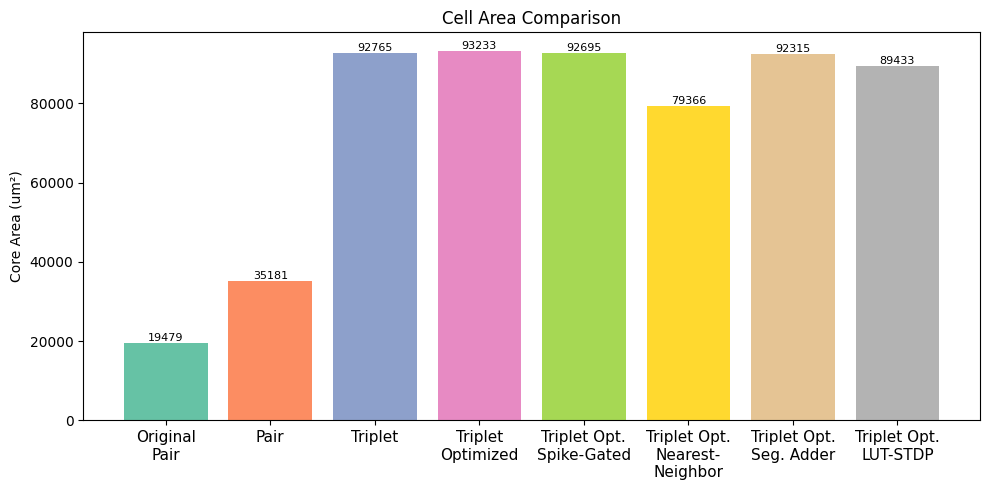

Saved: area_comparison.png, area_comparison.pdf


In [65]:
if not df.empty:
    import textwrap
    wrapped_labels = [textwrap.fill(l, width=12) for l in df["Design"]]

    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.bar(range(len(df)), df["Area (um2)"], color=plt.cm.Set2.colors[:len(df)])
    ax.set_ylabel("Core Area (um²)")
    ax.set_title("Cell Area Comparison")
    ax.bar_label(bars, fmt="%.0f", fontsize=8)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(wrapped_labels, ha="center", fontsize=11)

    plt.tight_layout()
    # fig.savefig("area_comparison.png", dpi=200, bbox_inches="tight")
    # fig.savefig("area_comparison.pdf", bbox_inches="tight")
    plt.show()
    print("Saved: area_comparison.png, area_comparison.pdf")
else:
    print("No data to plot.")

## Power Breakdown Plot

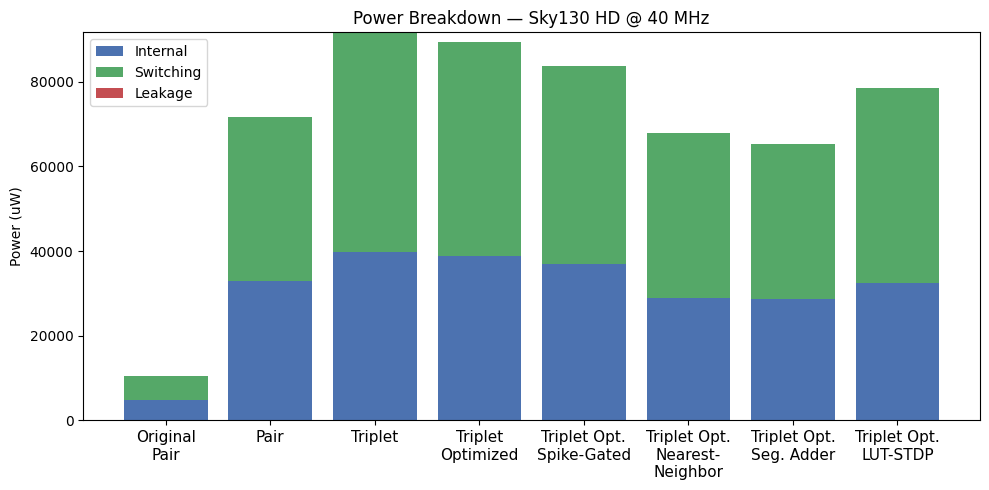

Saved: power_breakdown.png, power_breakdown.pdf


In [70]:
if not df.empty:
    import textwrap
    wrapped_labels = [textwrap.fill(l, width=12) for l in df["Design"]]

    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(len(df))
    width = 0.8

    internal = df["Internal Power (W)"].fillna(0).values * 1e6  # uW
    switching = df["Switching Power (W)"].fillna(0).values * 1e6
    leakage = df["Leakage Power (W)"].fillna(0).values * 1e6

    ax.bar(x, internal, width, label="Internal", color="#4C72B0")
    ax.bar(x, switching, width, bottom=internal, label="Switching", color="#55A868")
    ax.bar(x, leakage, width, bottom=internal + switching, label="Leakage", color="#C44E52")

    ax.set_xticks(x)
    ax.set_xticklabels(wrapped_labels, ha="center", fontsize=11)
    ax.set_ylabel("Power (uW)")
    ax.set_title("Power Breakdown — Sky130 HD @ 40 MHz")
    ax.legend()

    plt.tight_layout()
    # fig.savefig("power_breakdown.png", dpi=200, bbox_inches="tight")
    # fig.savefig("power_breakdown.pdf", bbox_inches="tight")
    plt.show()
    print("Saved: power_breakdown.png, power_breakdown.pdf")
else:
    print("No data to plot.")

## Timing Summary

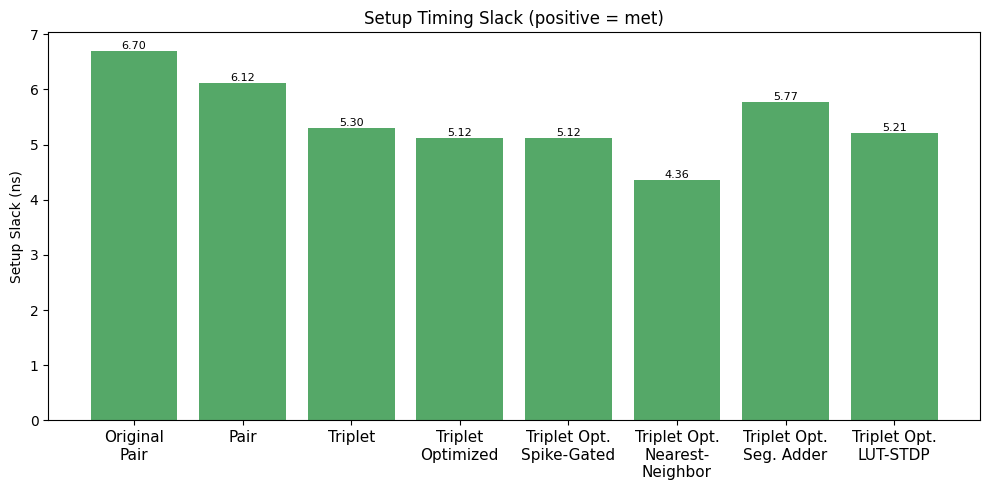

Saved: timing_summary.png, timing_summary.pdf


In [67]:
if not df.empty:
    import textwrap
    wrapped_labels = [textwrap.fill(l, width=12) for l in df["Design"]]
    CLOCK_PERIOD = 25  # ns

    fig, ax = plt.subplots(figsize=(10, 5))

    slack = df["Setup Slack (ns)"].fillna(0)
    colors = ["#55A868" if v >= 0 else "#C44E52" for v in slack]
    bars = ax.bar(range(len(df)), slack, color=colors)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel("Setup Slack (ns)")
    ax.set_title("Setup Timing Slack (positive = met)")
    ax.bar_label(bars, fmt="%.2f", fontsize=8)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(wrapped_labels, ha="center", fontsize=11)

    plt.tight_layout()
    # fig.savefig("timing_summary.png", dpi=200, bbox_inches="tight")
    # fig.savefig("timing_summary.pdf", bbox_inches="tight")
    plt.show()
    print("Saved: timing_summary.png, timing_summary.pdf")
else:
    print("No data to plot.")

## Export Summary CSV

In [68]:
# if not df.empty:
#     export_cols = [c for c in df.columns if not c.startswith("_")]
#     df[export_cols].to_csv("ppa_summary.csv", index=False)
#     print("Saved: ppa_summary.csv")
#     print("\nFigures saved: area_comparison.{png,pdf}, power_breakdown.{png,pdf}, timing_summary.{png,pdf}")
# else:
#     print("No data to export.")